# Demonstration of the QLSAs workflow on IBM Backends

In [47]:
# Set system path

from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p  # fallback


repo_root = find_repo_root()
print(repo_root)

# This repo uses a "src layout" (the Python package lives in <repo>/src/qlsas),
# but the repo is not installed as a package. Add <repo>/src to sys.path.
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# Also add the repo root so you can import top-level modules like
# `linear_systems_problems.random_matrix_generator`.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

/Users/adrianharkness/QCOL_COPT/HHL/QLSAs


In [48]:
# Import QLSAs modules

from qlsas.algorithms.hhl.hhl import HHL
from qlsas.data_loader import StatePrep
from qlsas.transpiler import Transpiler
from qlsas.executer import Executer
from qlsas.post_processor import Post_Processor
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner
from qlsas.ibm_options import IBMExecutionOptions
from linear_systems_problems.random_matrix_generator_v2 import generate_problem

# Import other modules
from datetime import datetime
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## Step 0: **Define** the (classical) problem

In [49]:
n = 16
prob = generate_problem(n=n, cond_number=5, sparsity=0.5, seed=0)
A, b = prob["A"], prob["b"]

A  = A / np.linalg.norm(b)
b = b / np.linalg.norm(b)

print(f"A: {A}")
print()
print(f"b: {b}")
print()
print(f"min eigenvalue: {np.min(np.linalg.eigvalsh(A))}")
print(f"max eigenvalue: {np.max(np.linalg.eigvalsh(A))}")
print(f"condition number: {np.linalg.cond(A)}")
print(f"sparsity: {np.sum(A != 0) / (n * n)}")

A: [[ 3.45819472e-01  0.00000000e+00  8.70829253e-02  0.00000000e+00
   0.00000000e+00  2.07776774e-02 -2.15292759e-04  8.40732190e-02
  -5.65429621e-02 -2.39700939e-02  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.27825956e-02  0.00000000e+00]
 [ 0.00000000e+00  4.45221846e-01  0.00000000e+00 -6.02217307e-02
   6.30294964e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  3.09551501e-02 -1.05754048e-02
  -1.12381529e-01  1.99751195e-03  0.00000000e+00  0.00000000e+00]
 [ 8.70829253e-02  0.00000000e+00  4.63207679e-01  2.61420427e-02
   0.00000000e+00  9.47500692e-02  7.04741613e-02  0.00000000e+00
   6.35662003e-02  0.00000000e+00  0.00000000e+00  1.06432418e-02
   0.00000000e+00  0.00000000e+00  7.31762652e-02 -6.26494001e-03]
 [ 0.00000000e+00 -6.02217307e-02  2.61420427e-02  4.14430482e-01
   0.00000000e+00  0.00000000e+00  1.03756564e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.59374092e-02
  -3

## Step 1: **Map** problem to quantum circuits and operators

In [50]:
oracle = "unary" # "classical" or "quantum"

hhl = HHL(
    state_prep = StatePrep(method='default'),
    readout = 'measure_x', # 'measure_x' or 'swap_test'
    num_qpe_qubits = int(math.log2(len(b))),
    eig_oracle = oracle
)

In [51]:
hhl_circuit = hhl.build_circuit(A, b) # swap_test_vector = np.ones(len(b)) / np.linalg.norm(np.ones(len(b)))
hhl_circuit.draw(output='mpl', fold=-1)

## Step 2: **Optimize** for target hardware

In [52]:
service = QiskitRuntimeService(name="QLSAs")
service.backends()

[<IBMBackend('ibm_boston')>,
 <IBMBackend('ibm_pittsburgh')>,
 <IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_miami')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_torino')>]

In [53]:
# Define a backend

# use a specific hardware backend
# backend = service.backend("ibm_pittsburgh")

# or use the least busy backend
# backend = service.least_busy(operational=True, min_num_qubits=hhl_circuit.num_qubits)
# print("Backend: ", backend)

# or use a simulator
# noiseless:
backend = AerSimulator()

# noisy:
# Add depolarizing error to all single qubit u1, u2, u3 gates
# noise_model = NoiseModel()
# error_prob = .05
# error = depolarizing_error(error_prob, 1)
# noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3"])
# backend = AerSimulator(noise_model=noise_model)

In [54]:
# Transpile the circuit

# Decompose high-level gates (HamiltonianGate, StatePreparation, …) into elementary
# operations first so the baseline is a fair comparison against the optimised circuit.
_decomposer = Transpiler(circuit=hhl_circuit, backend=backend, optimization_level=0)
_decomposed = _decomposer.optimize()
orig_2q    = _decomposed.size(lambda x: x.operation.num_qubits == 2)
orig_total = _decomposed.size()
orig_depth = _decomposed.depth(lambda x: x.operation.num_qubits == 2)

transpiler = Transpiler(circuit=hhl_circuit, backend=backend, optimization_level=3)
transpiled_hhl_circuit = transpiler.optimize()

opt_2q    = transpiled_hhl_circuit.size(lambda x: x.operation.num_qubits == 2)
opt_total = transpiled_hhl_circuit.size()
opt_depth = transpiled_hhl_circuit.depth(lambda x: x.operation.num_qubits == 2)

def _pct(before, after):
    return 100 * (before - after) / before if before else float("nan")

print(f"{'Metric':<18} {'Original':>10} {'Optimised':>10} {'Reduction':>10}")
print("-" * 52)
print(f"{'2q-gate count':<18} {orig_2q:>10} {opt_2q:>10} {_pct(orig_2q, opt_2q):>9.1f}%")
print(f"{'Total gates':<18} {orig_total:>10} {opt_total:>10} {_pct(orig_total, opt_total):>9.1f}%")
print(f"{'2q-depth':<18} {orig_depth:>10} {opt_depth:>10} {_pct(orig_depth, opt_depth):>9.1f}%")
print(f"\nOperator counts (optimised): {transpiled_hhl_circuit.count_ops()}")

Metric               Original  Optimised  Reduction
----------------------------------------------------
2q-gate count            1497       1493       0.3%
Total gates              2797       2473      11.6%
2q-depth                 1475       1473       0.1%

Operator counts (optimised): OrderedDict([('cu', 784), ('ccx', 760), ('crz', 576), ('u2', 170), ('cx', 121), ('h', 16), ('ry', 16), ('cp', 12), ('barrier', 9), ('p', 8), ('measure', 5), ('u3', 3), ('u1', 2)])


## Step 3: **Execute** on target hardware

In [55]:
executer = Executer()

result = executer.run(
    transpiled_circuit = transpiled_hhl_circuit, 
    backend = backend,
    shots = 1000
    )

>>> Job ID: 66803d15-7f43-4b3f-9fce-146747b3e439
>>> Job Status: DONE      


## Step 4: **Process** result to obtain classical solution

In [56]:
processor = Post_Processor()
solution, success_rate, residual = processor.process_tomography(result, A, b)

total shots: 1000
num_successful_shots: 159
success rate: 0.159
solver residual: 0.15532485855648673


## Wrap steps 1-4 together in a solver:

In [57]:
hhl_solver = QuantumLinearSolver(
    qlsa = hhl,
    backend = backend,
    target_successful_shots = 1000,
    shots_per_batch = 5000,
    optimization_level = 3
    )

## Integrate **Iterative Refinement** to improve accuracy

IR Iteration: 0
>>> Job ID: a2183fc1-a41b-426c-9a3a-aa56f65f0400
>>> Job Status: DONE      
>>> Job ID: ddd44a64-f5a2-47f7-889f-c3c30416086b
>>> Job Status: DONE      
  residual: 0.1001, error: 0.1020, alpha: 3.6506

IR Iteration: 1
>>> Job ID: c99c8b7e-872a-4a08-9dfb-dcd56057817e
>>> Job Status: DONE      
>>> Job ID: cf5cd87d-22e2-4b3f-b1d6-341659d9f2d9
>>> Job Status: DONE      
  residual: 0.0160, error: 0.0171, alpha: 0.6836

IR Iteration: 2
>>> Job ID: ffdb79ac-1f66-4869-a719-747cf4fa9454
>>> Job Status: DONE      
>>> Job ID: 58817594-7a04-4ce5-aa68-aa880516cee7
>>> Job Status: DONE      
  residual: 0.0023, error: 0.0032, alpha: 0.2262

IR Iteration: 3
>>> Job ID: 9a94cb9d-c131-4719-9a7b-62f3ac64762b
>>> Job Status: DONE      
  residual: 0.0004, error: 0.0004, alpha: 0.1042

IR Iteration: 4
>>> Job ID: 538033e1-5ffa-4bd6-9f42-1c7ff0119701
>>> Job Status: DONE      
>>> Job ID: 2ca08323-f133-43be-aaf5-3872569965a8
>>> Job Status: DONE      
  residual: 0.0000, error: 0.0001, a

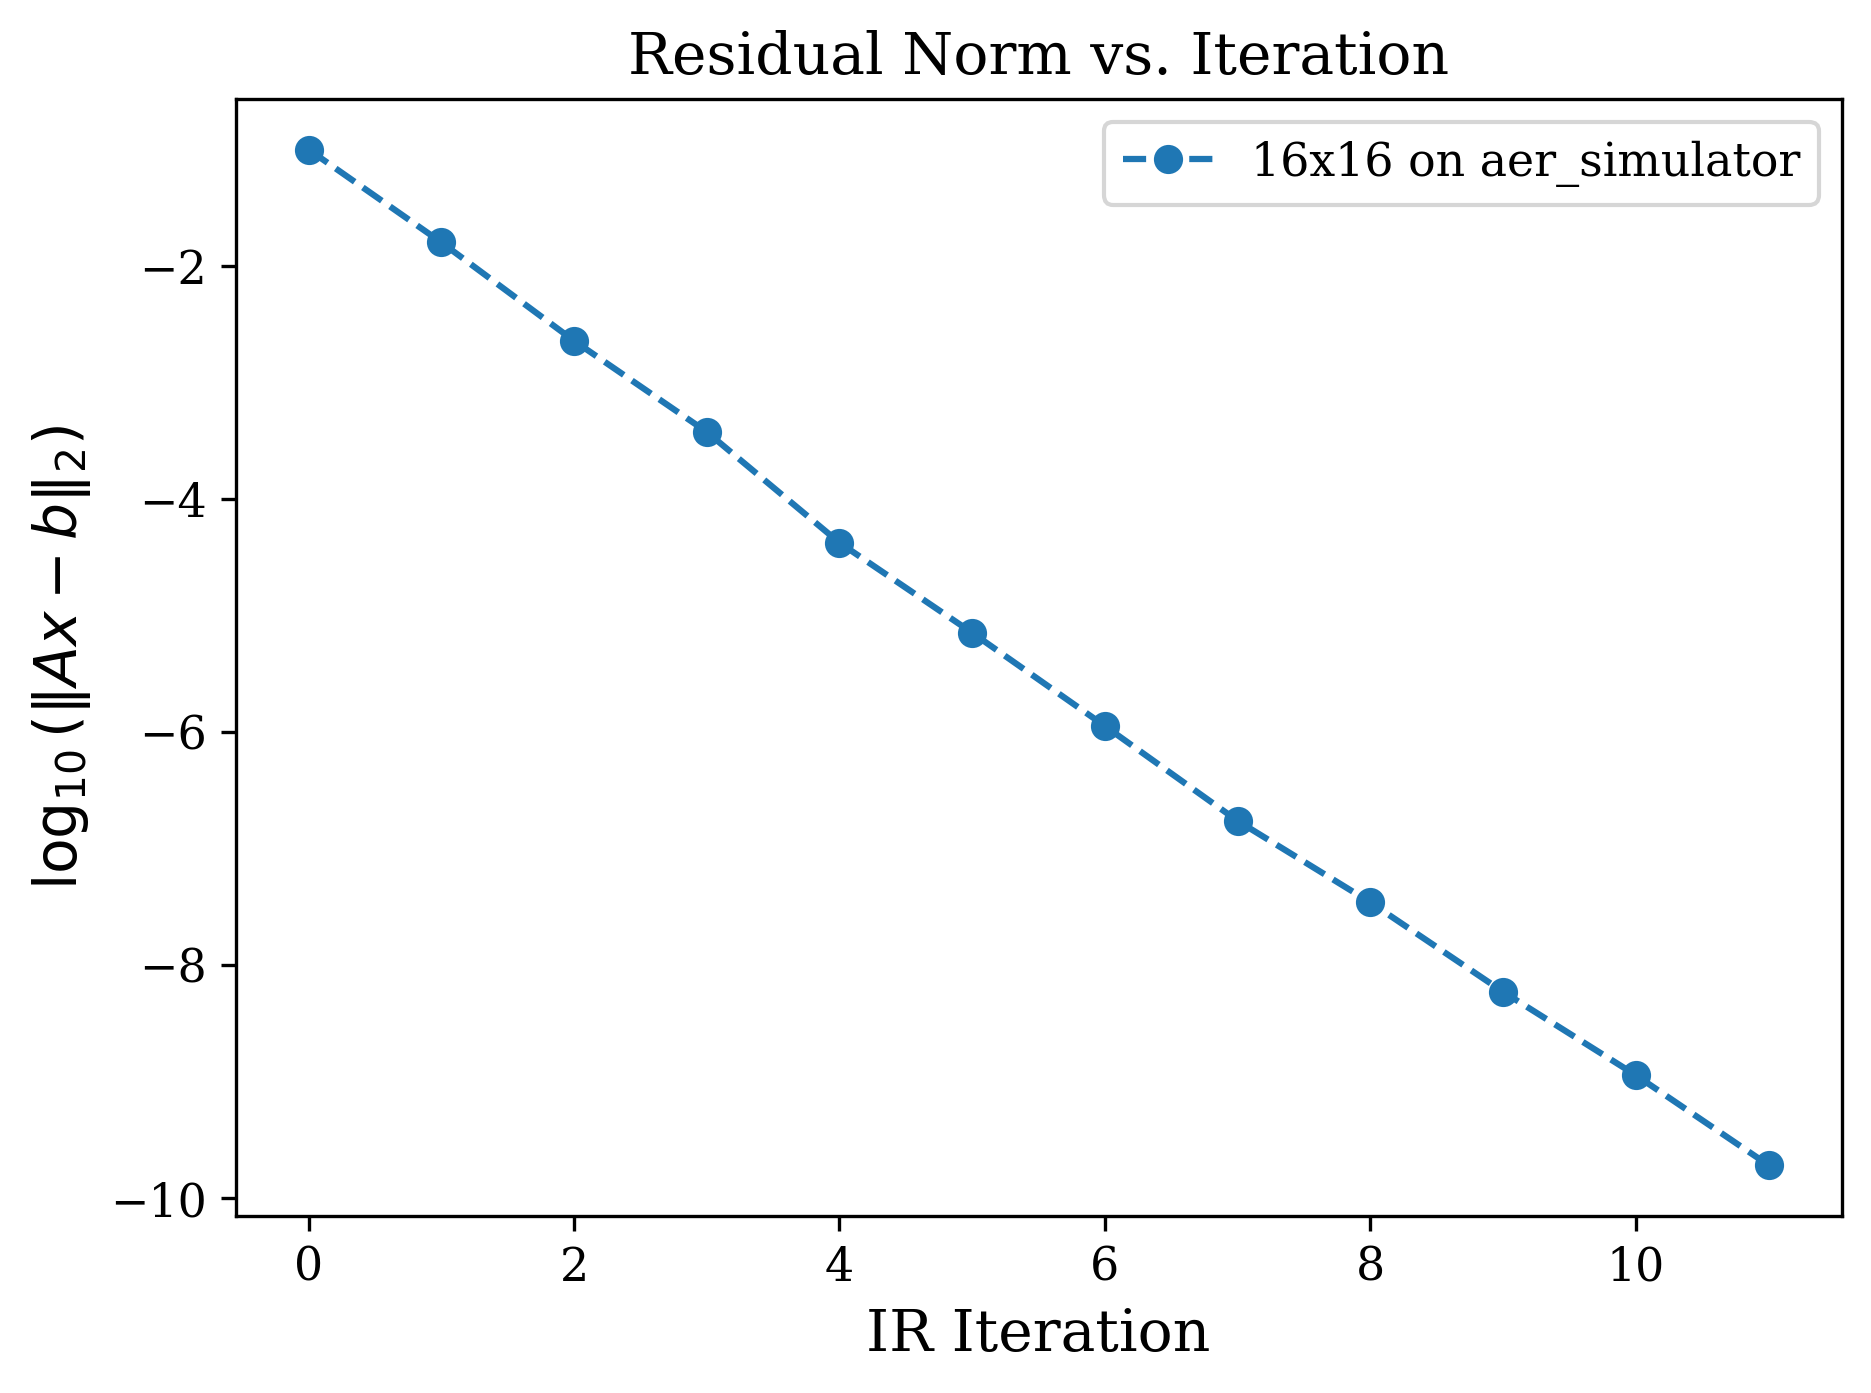

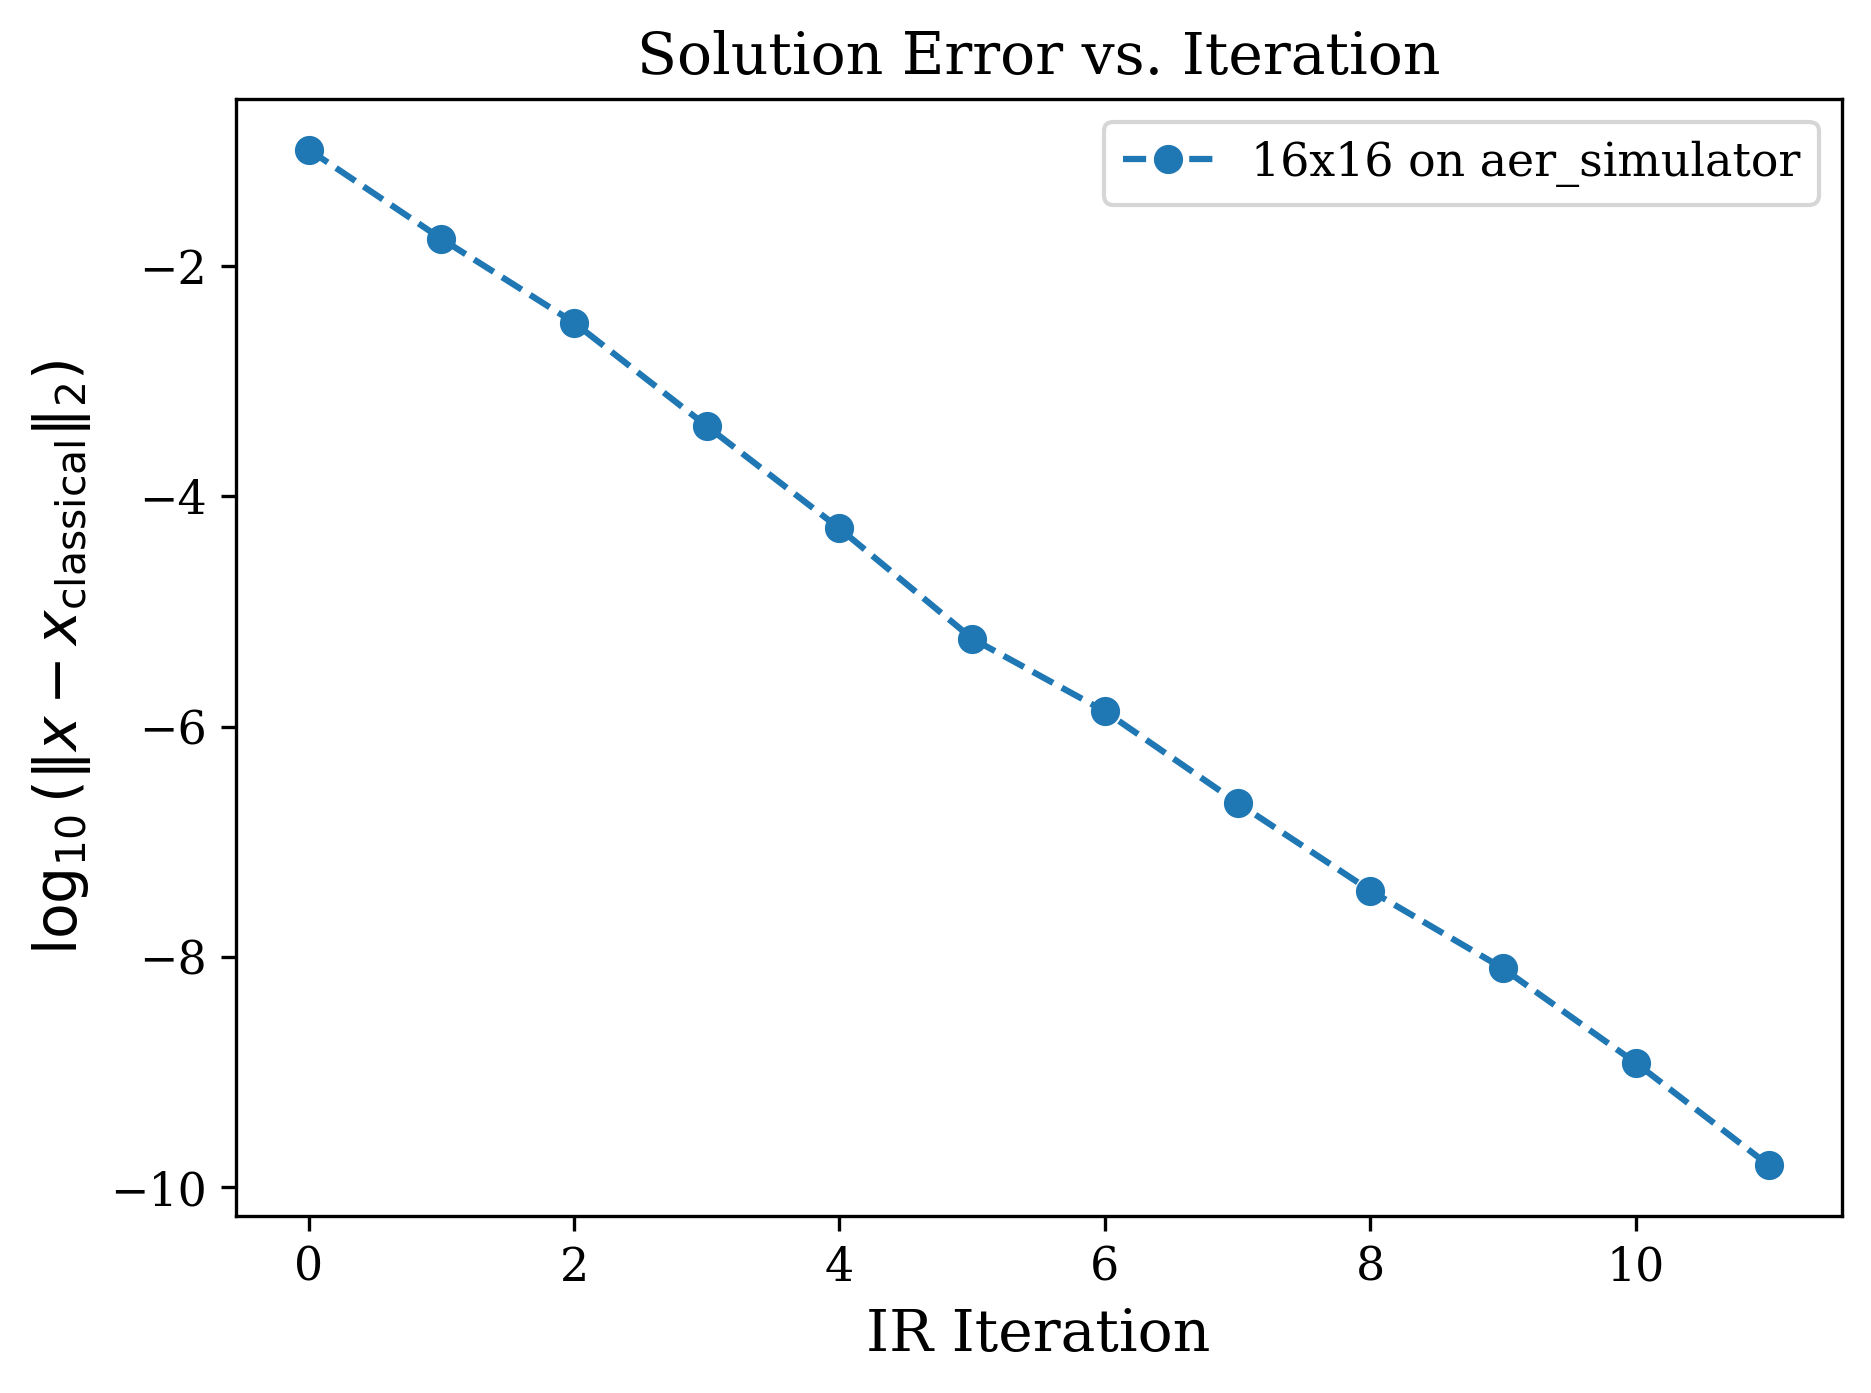

In [58]:
refiner = Refiner(A = A, b = b, solver = hhl_solver)
refined_solution = refiner.refine(precision = 1e-9, max_iter = 15, plot=True)

## Add error mitigation:

In [59]:
ibm_options = IBMExecutionOptions(
    enable_error_mitigation=True,
    enable_dynamical_decoupling=True,
    dd_sequence_type="XX",
    enable_gate_twirling=True
)

In [60]:
error_mitigated_hhl_solver = QuantumLinearSolver(
    qlsa = hhl,
    backend = backend,
    ibm_options = ibm_options,
    target_successful_shots = 1000,
    shots_per_batch = 5000,
    optimization_level = 3,
)

IR Iteration: 0
>>> Job ID: 7978b1a7-64e5-4a54-a093-b7f27fd29be5
>>> Job Status: DONE      
>>> Job ID: 132588f2-35ef-4844-8f62-01a66c17b466
>>> Job Status: DONE      
  residual: 0.1240, error: 0.1048, alpha: 3.6112

IR Iteration: 1
>>> Job ID: df805a7f-317d-4018-8bd7-ef7a51bec406
>>> Job Status: DONE      
>>> Job ID: 5cb1d002-67fe-4d46-8bf2-c078b4a94f8b
>>> Job Status: DONE      
  residual: 0.0135, error: 0.0193, alpha: 0.7190

IR Iteration: 2
>>> Job ID: fc70fb2d-c9ea-44a5-bb56-1b3c407e479e
>>> Job Status: DONE      
  residual: 0.0024, error: 0.0028, alpha: 0.2786

IR Iteration: 3
>>> Job ID: 549d2911-ab40-458b-9217-a7a8af68f692
>>> Job Status: DONE      
  residual: 0.0005, error: 0.0006, alpha: 0.0818

IR Iteration: 4
>>> Job ID: 4e0acc3e-2187-4a40-a176-57abba86e52e
>>> Job Status: DONE      
  residual: 0.0001, error: 0.0001, alpha: 0.0312

IR Iteration: 5
>>> Job ID: 77e0031e-96c2-4305-9a6a-27e1447f7d9e
>>> Job Status: DONE      
  residual: 0.0000, error: 0.0000, alpha: 0.01

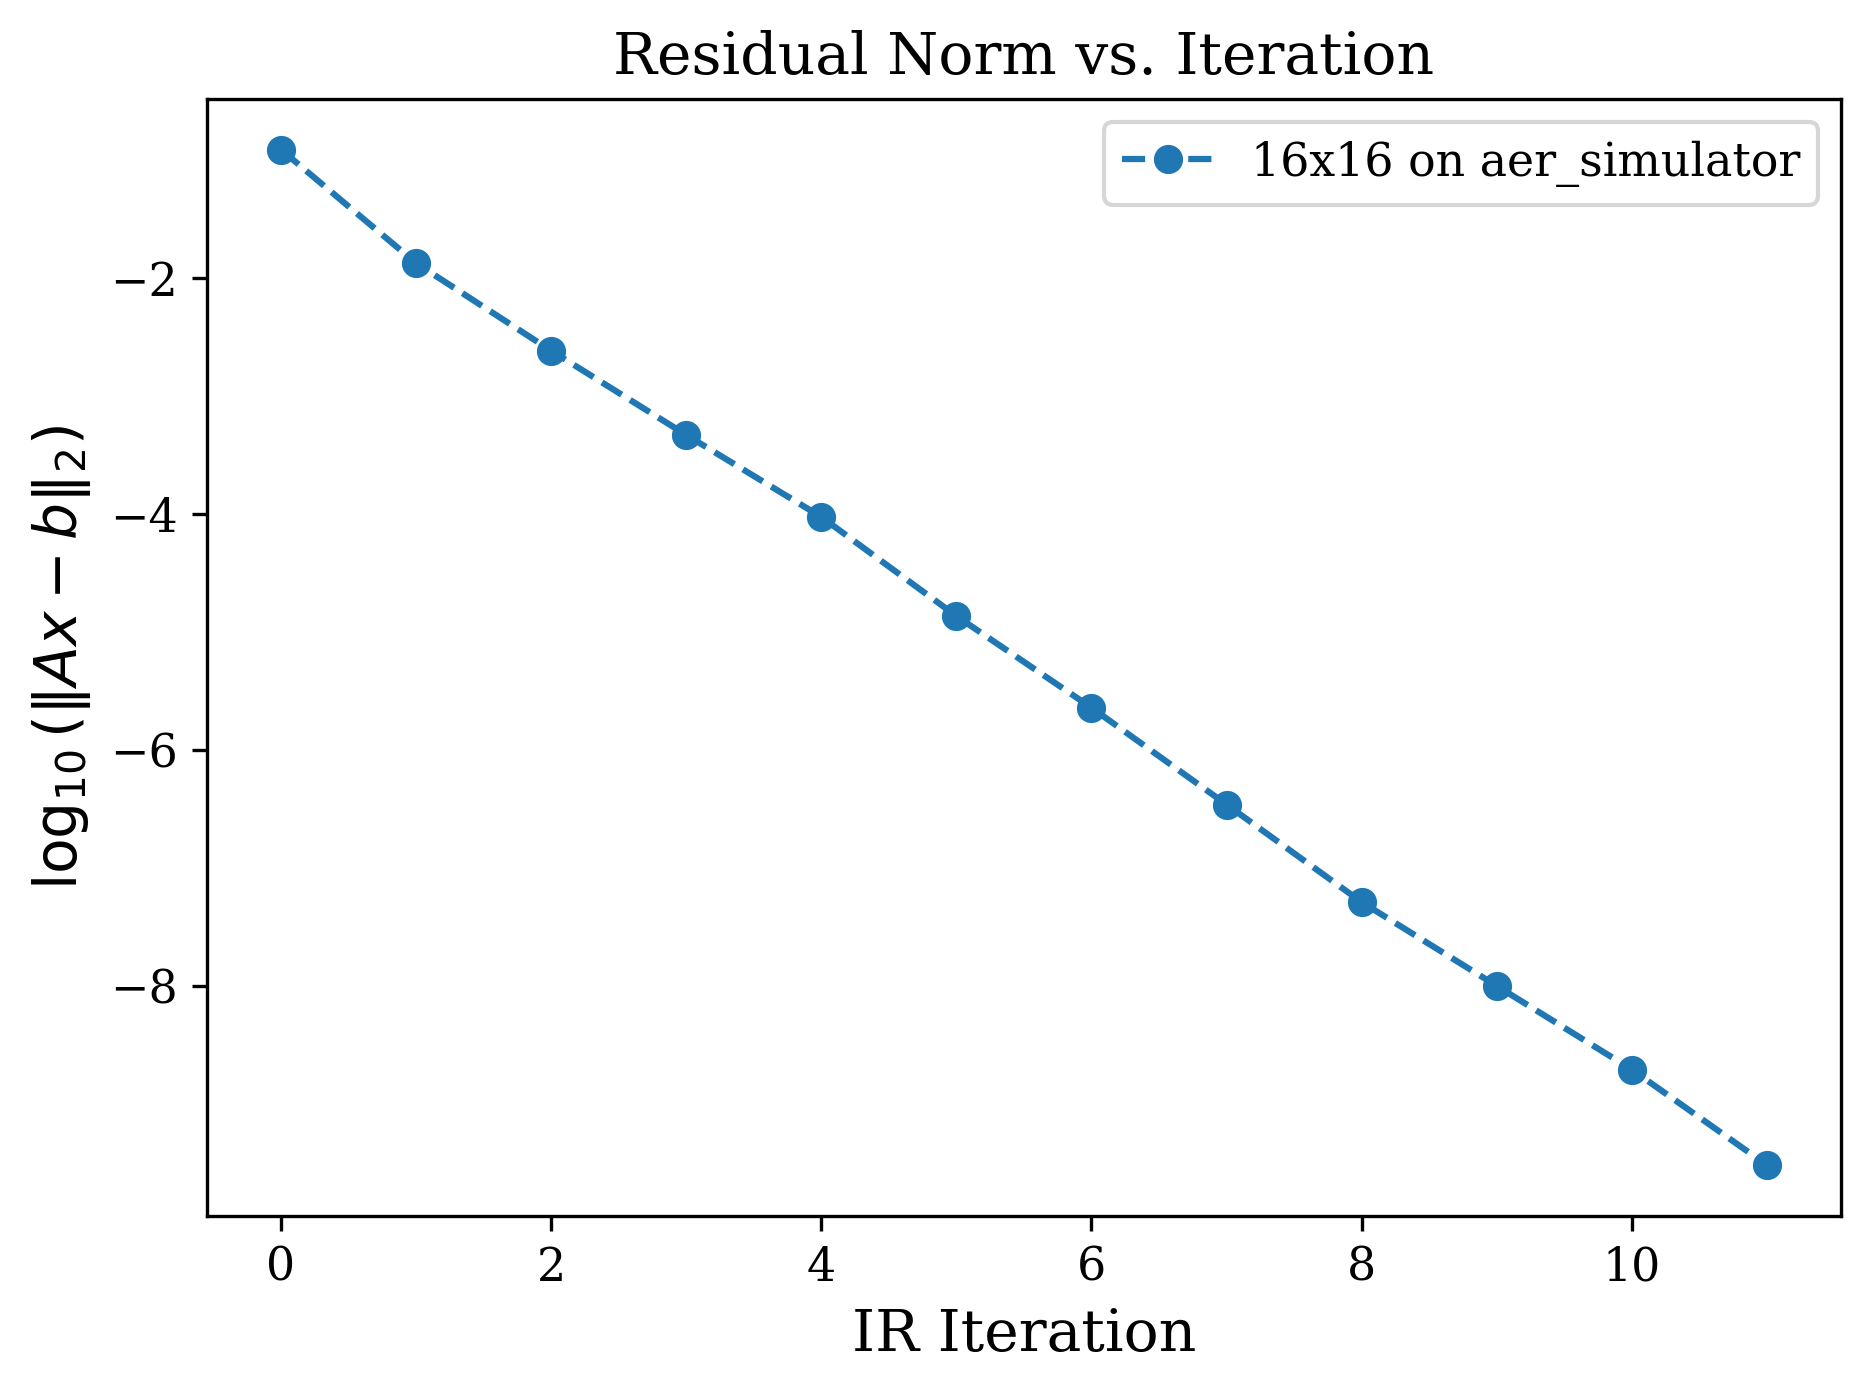

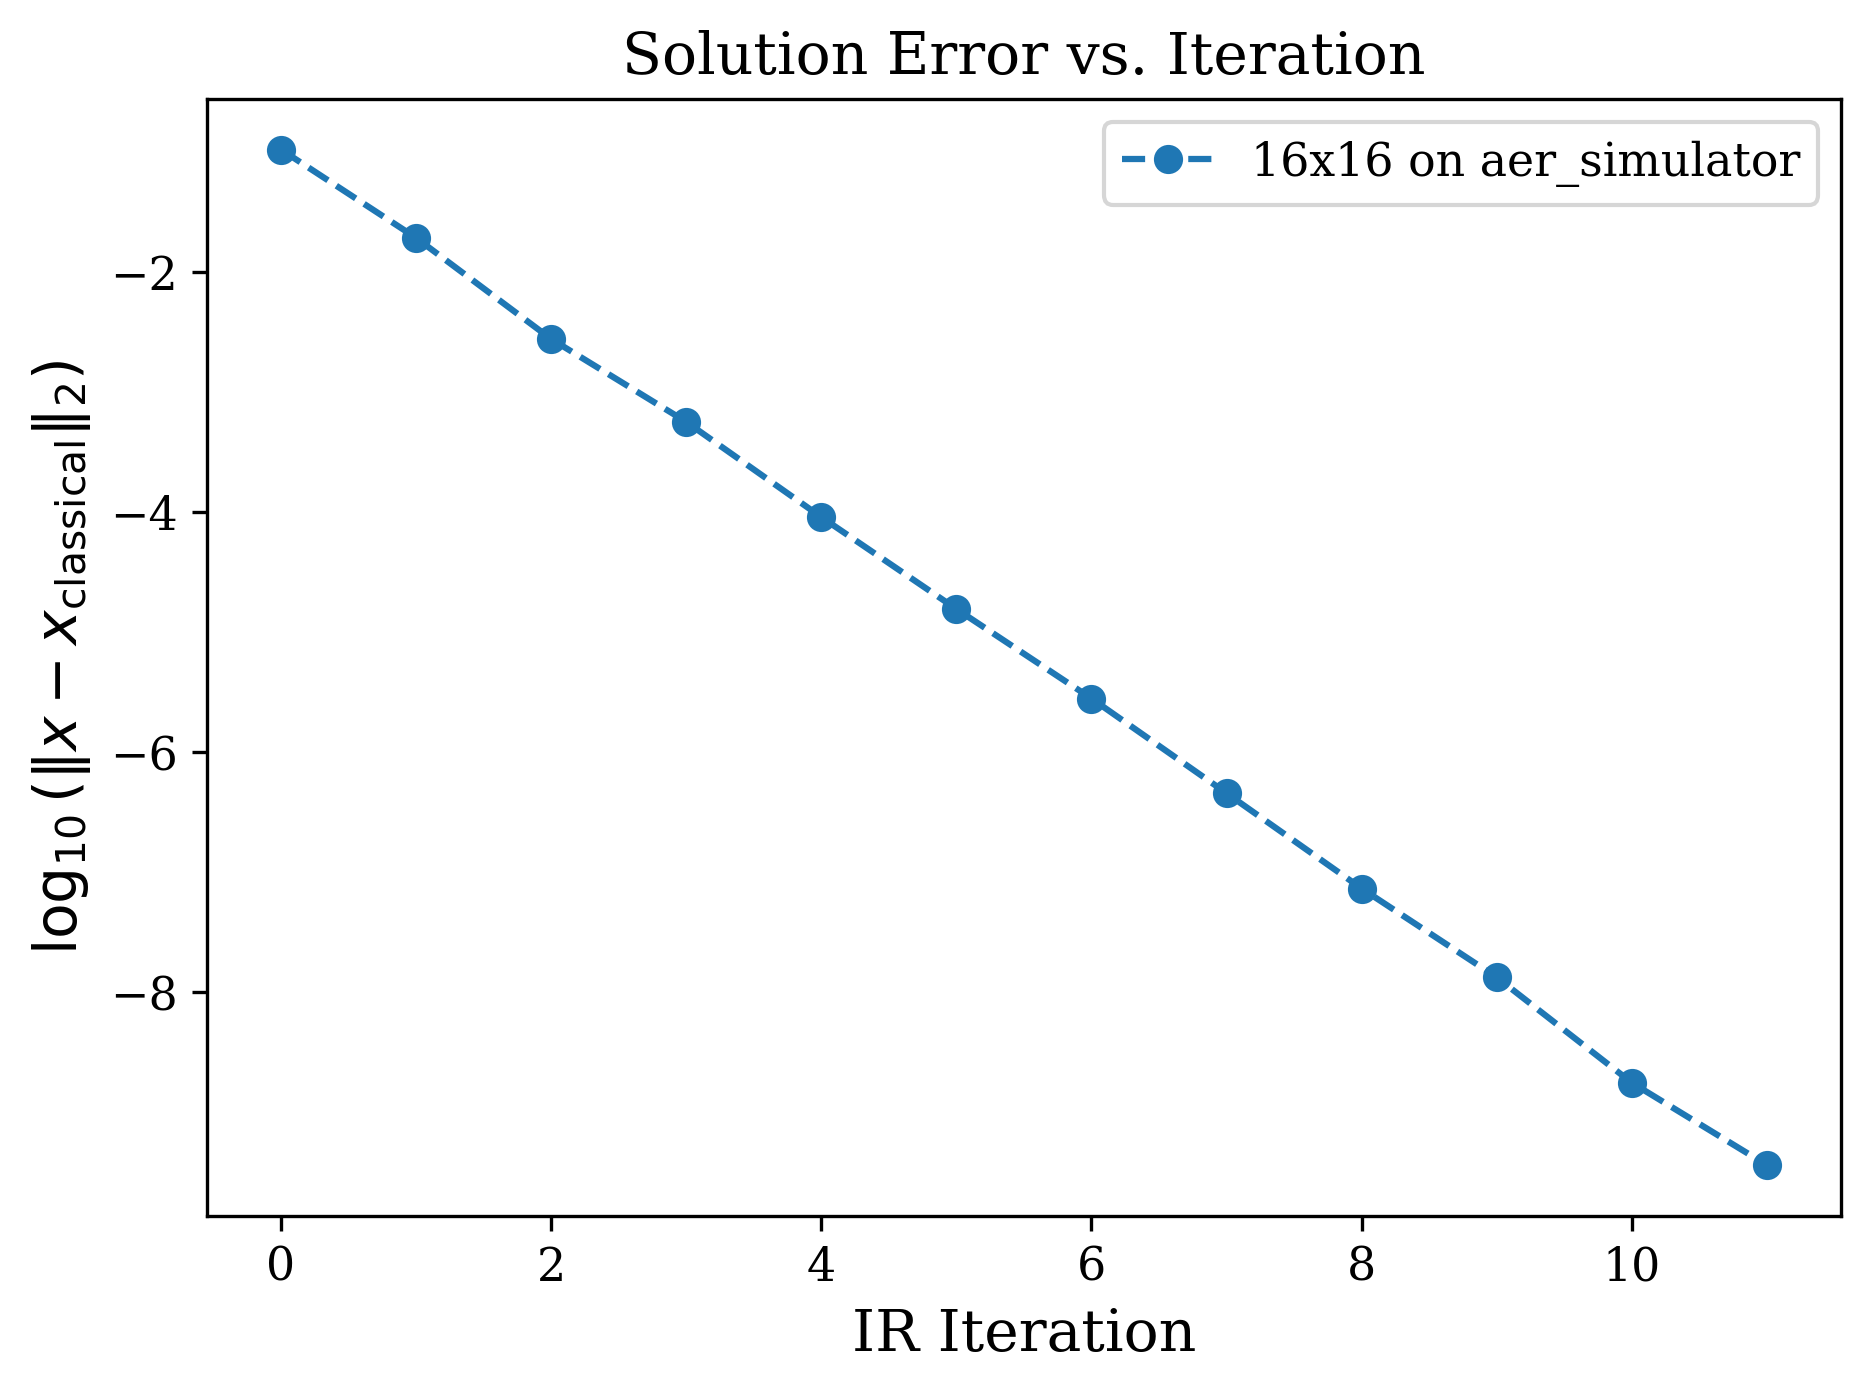

In [61]:
error_mitigated_refiner = Refiner(A = A, b = b, solver = error_mitigated_hhl_solver)
error_mitigated_refined_solution = error_mitigated_refiner.refine(precision = 1e-9, max_iter = 15, plot=True)

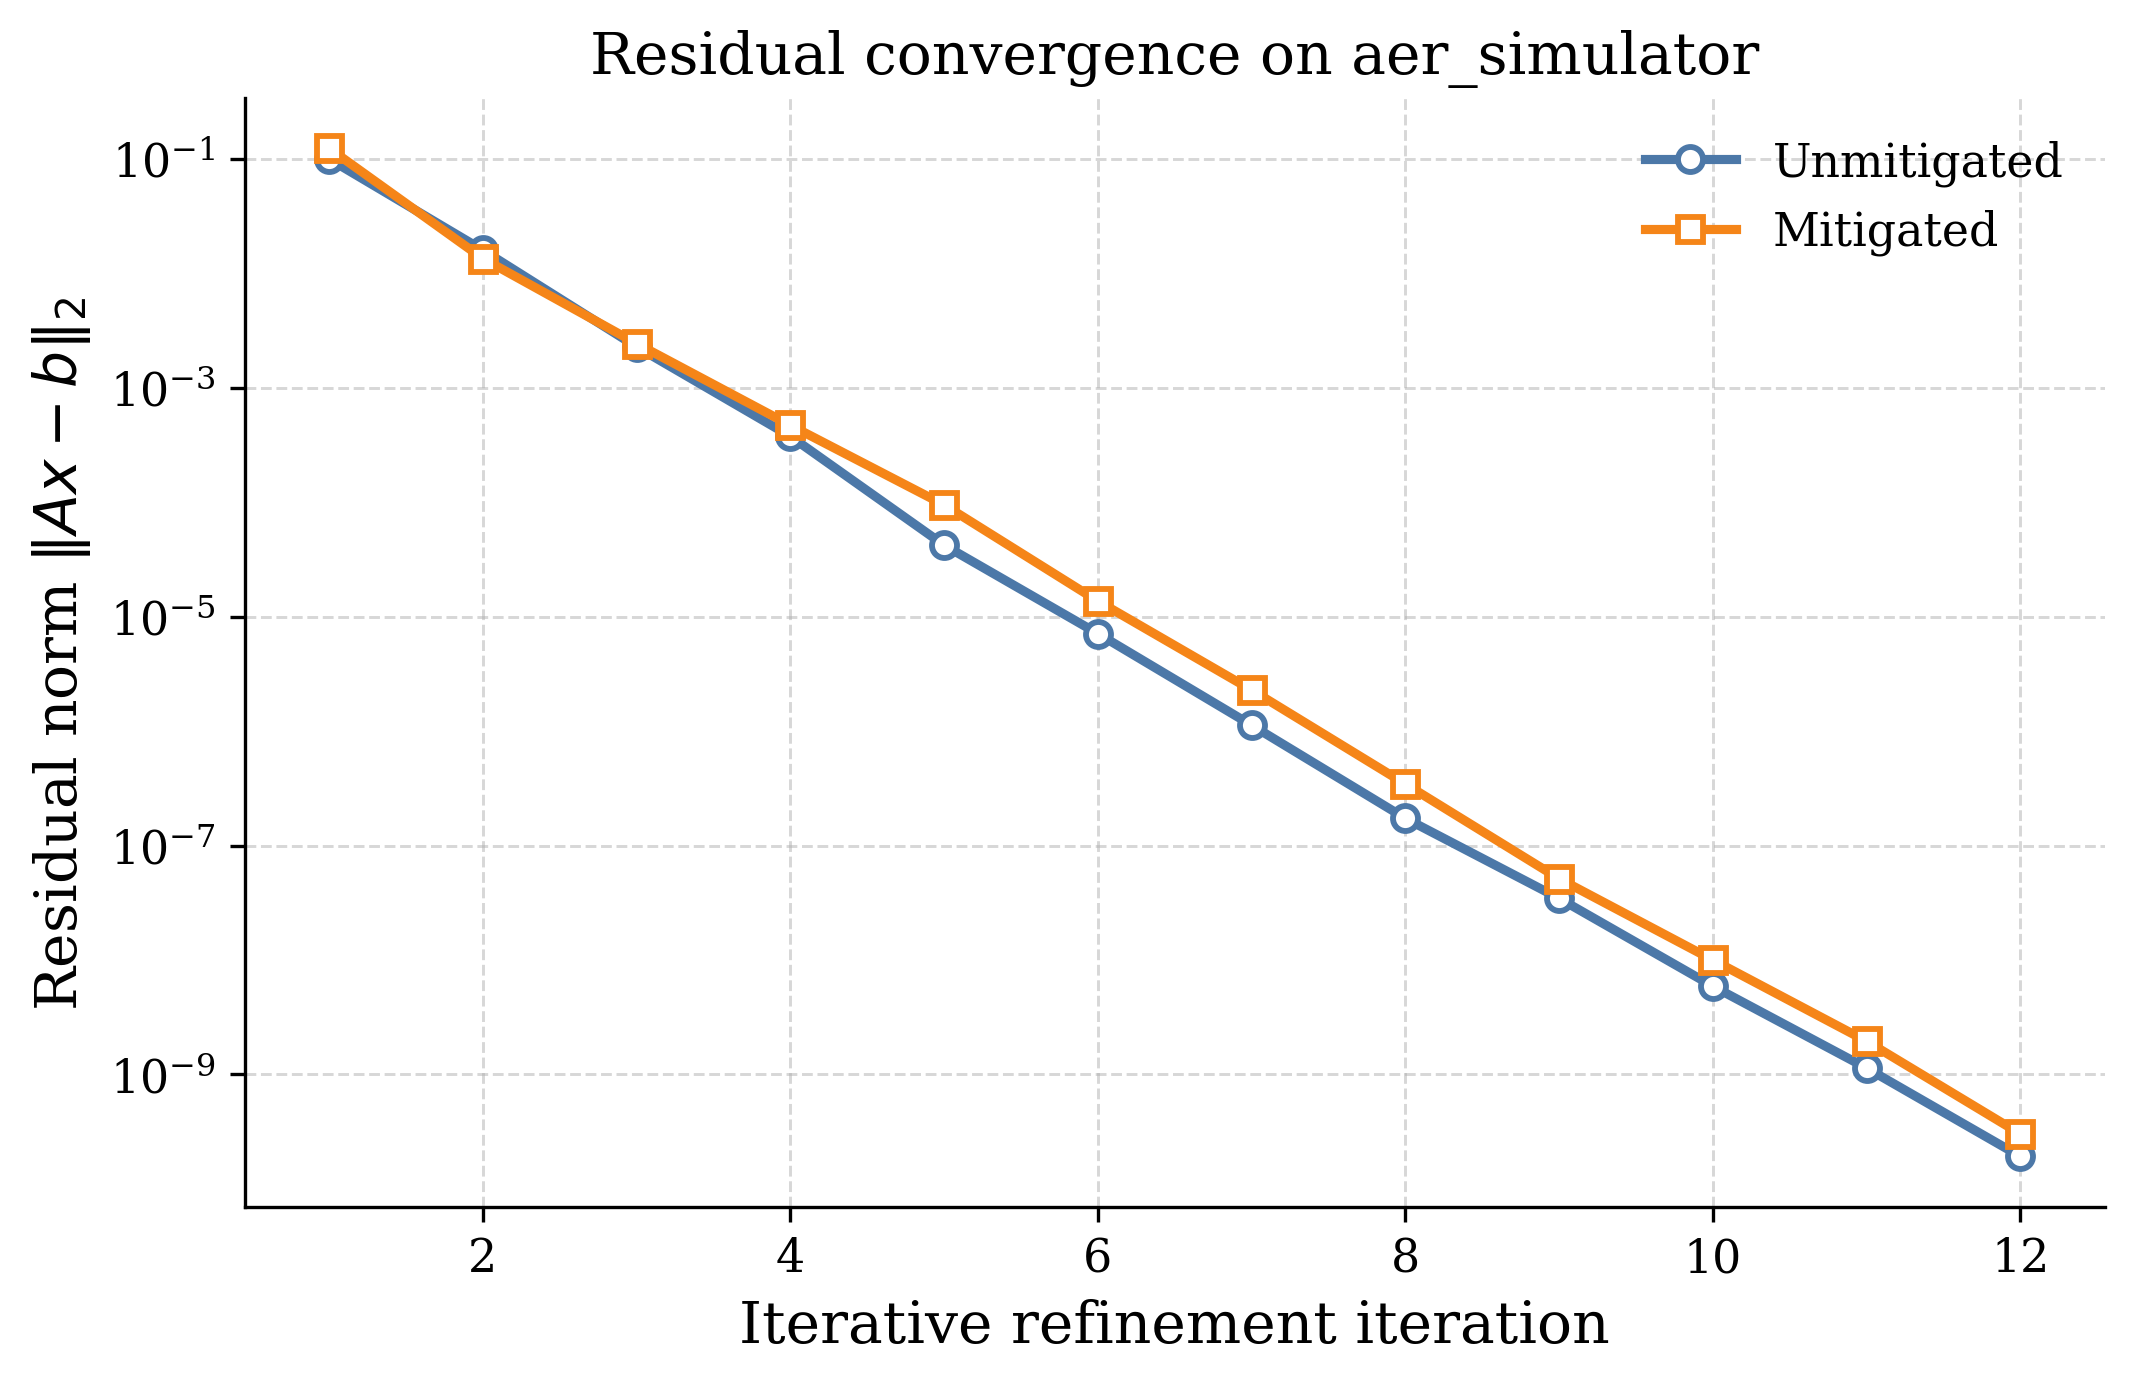

In [62]:
residuals = np.asarray(refined_solution["residuals"], dtype=float)
mitigated_residuals = np.asarray(error_mitigated_refined_solution["residuals"], dtype=float)

iterations = np.arange(1, len(residuals) + 1)
mitigated_iterations = np.arange(1, len(mitigated_residuals) + 1)

fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)
ax.plot(
    iterations,
    residuals,
    label="Unmitigated",
    color="#4C78A8",
    marker="o",
    linewidth=2.2,
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.4,
)
ax.plot(
    mitigated_iterations,
    mitigated_residuals,
    label="Mitigated",
    color="#F58518",
    marker="s",
    linewidth=2.2,
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.4,
)

backend_label = getattr(backend, "name", str(backend))
ax.set_yscale("log")
ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel(r"Residual norm $\|Ax-b\|_2$")
ax.set_title(f"Residual convergence on {backend_label}")
ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)
ax.legend(frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [63]:
import pickle

solutions_dir = repo_root / "data" / "solutions"
solutions_dir.mkdir(parents=True, exist_ok=True)

solution_dicts = {
    "refined_solution": refined_solution,
    "error_mitigated_refined_solution": error_mitigated_refined_solution,
}

for name, solution in solution_dicts.items():
    out_path = solutions_dir / f"{name}.pkl"
    with open(out_path, "wb") as f:
        pickle.dump(solution, f)